In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
#데이터 분석을 위한 기본적인 세팅이라고 생각

In [3]:
# os.environ을 이용하여 Kaggle API Username, Key 세팅하기
os.environ ['KAGGLE_USERNAME'] = 'injun'
os.environ ['KAGGLE_KEY'] ='KGAT_531c65db054a83d5148736eb33c86248'

In [49]:
# Linux 명령어로 Kaggle API를 이용하여 데이터셋 다운로드하기 (!kaggle ~)
# Linux 명령어로 압축 해제하기

!kaggle datasets download -d andrewmvd/heart-failure-clinical-data
# !kaggle datasets download -d "이부분이 매번 바뀐다고 생각하면 된다."
!unzip -o heart-failure-clinical-data.zip

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data
License(s): Attribution 4.0 International (CC BY 4.0)
heart-failure-clinical-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  heart-failure-clinical-data.zip
  inflating: heart_failure_clinical_records_dataset.csv  


In [50]:
!ls

heart-failure-clinical-data.zip		    xAPI-Edu-Data.csv
heart_failure_clinical_records_dataset.csv  xAPI-Edu-Data.zip
sample_data


In [51]:
# pd.read_csv()로 csv파일 읽어들이기
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [52]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


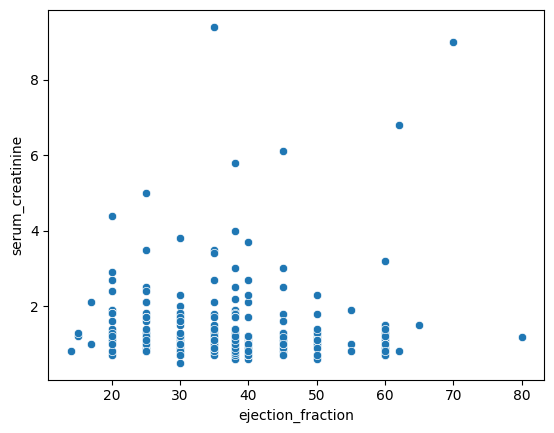

In [65]:
sns.scatterplot(x=df.ejection_fraction, y=df.serum_creatinine)
plt.show()

선형회귀분석

In [ ]:
import numpy as np

class LinearRegression:
    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        
        X = np.hstack((np.ones((X.shape[0], 1)), X))

      
        self.weights = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

       
        self.bias = self.weights[0]
        self.weights = self.weights[1:]

    def predict(self, X):
        
        X = np.hstack((np.ones((X.shape[0], 1)), X))

        
        y_pred = X.dot(np.hstack((self.bias, self.weights)))

        return y_pred

In [ ]:
def train_test_split(dataframe, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)

    
    indices = np.random.permutation(len(dataframe))

    
    test_samples = int(len(dataframe) * test_size)

    
    test_indices = indices[:test_samples]
    train_indices = indices[test_samples:]

    
    train_data = dataframe.iloc[train_indices]
    test_data = dataframe.iloc[test_indices]

    return train_data, test_data

In [ ]:
def mean_squared_error(y_true, y_pred):
    
    squared_errors = [(y_true[i] - y_pred[i]) ** 2 for i in range(len(y_true))]

    
    mse = sum(squared_errors) / len(y_true)

    return mse

In [ ]:
def r_squared(y_true, y_pred):
    
    mean_y_true = sum(y_true) / len(y_true)

    
    tss = sum((y - mean_y_true) ** 2 for y in y_true)

    
    rss = sum((y_true[i] - y_pred[i]) ** 2 for i in range(len(y_true)))

    
    r2 = 1 - (rss / tss)

    return r2

In [ ]:

train_data, test_data = train_test_split(df, random_state=42)

# 변수 설정
X_train = np.array(train_data.ejection_fraction).reshape(-1, 1)
y_train = np.array(train_data.serum_sodium)

X_test = np.array(test_data.ejection_fraction).reshape(-1, 1)
y_test = np.array(test_data.serum_sodium)

# 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측
predictions = model.predict(X_test)

# 평가
y_pred_train = model.predict(X_train)

print("MSE:", mean_squared_error(y_test, predictions))
print("R-squared:", r_squared(y_test, predictions))


MSE: 18.31633963853029
R-squared: -0.02266670326442566


로지스틱회귀분석

In [ ]:
import numpy as np

class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=5000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)  # 안정성을 위해서
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            # Gradient descent
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X, threshold=0.5):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        y_predicted_cls = [1 if i > threshold else 0 for i in y_predicted]
        return np.array(y_predicted_cls)



In [ ]:
# 2) Train/Test Split (from scratch)
def train_test_split(dataframe, test_size=0.2, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    indices = np.random.permutation(len(dataframe))
    test_samples = int(len(dataframe) * test_size)

    test_indices = indices[:test_samples]
    train_indices = indices[test_samples:]

    train_data = dataframe.iloc[train_indices]
    test_data = dataframe.iloc[test_indices]

    return train_data, test_data





In [ ]:
# 3) Accuracy
def accuracy(y_true, y_pred):
    correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    return correct / len(y_true)

In [ ]:
# 4) Run (X = time, y = DEATH_EVENT) 
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

# 변수 설정 
X_train = np.array(train_data.time).reshape(-1, 1)
y_train = np.array(train_data.DEATH_EVENT)

X_test = np.array(test_data.time).reshape(-1, 1)
y_test = np.array(test_data.DEATH_EVENT)

# 표준화
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1.0

X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

# 모델 학습/예측/평가
model = LogisticRegression(learning_rate=0.01, n_iterations=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy(y_test, y_pred))

Accuracy: 0.7457627118644068
